# 07 — ARIMA and SARIMA: Autoregression, Differencing, Moving Averages

## Where this sits on the ladder

```
05a  Components (level, trend, seasonality, noise)
  ↓  What patterns could exist?
05b  Baselines (Naive, Seasonal Naive, Moving Average)
  ↓  What do simple rules achieve?
06   Exponential Smoothing (SES/DES/TES)
  ↓  Explicit level / trend / seasonal states
07   ARIMA / SARIMA  ←  you are here
  ↓  Autocorrelation + stationarity + seasonal differencing
08   LSTM
09   LLM
```

> **Research question for this notebook:** Does explicitly modelling autocorrelation and stationarity (ARIMA) and seasonal autocorrelation (SARIMA) improve forecasts over smoothing, and where does the statistical view break down?

**How to read this notebook:** `Concept → Visual intuition → Mathematics → Worked example → Assumptions → Limitations → Implementation (leakage-safe) → Results → Business implications`. Every chart answers a question.

**Frozen experiment (unchanged):** M5 = 500 stratified series, Store Item Demand = 500 series (all), common window 2013-01-01 → 2016-05-22 (1,238 days), horizon $h=28$, 8 weekly origins, metrics MAE/RMSE/sMAPE/WAPE, seed 42. ARIMA runs full 500×8 on both datasets; SARIMA is demonstrated where seasonality is strong (Store Item Demand) on a 200-series subset to keep runtime within the frozen 900 s notebook budget — clearly labelled, methodology identical. Scale-free MASE/RMSSE are also registered in `05_experiments/config.json` and implemented in `11_src/metrics.py` for the downstream notebooks; the frozen tables here use the same MAE/RMSE/sMAPE/WAPE definitions as 05b/06.

**Pre-read:** 05a (components) explains *what* to look for; 03 (EDA) showed M5 weekly structure and ACF; 02b showed Store Item weekly strength. This notebook explains *how* ARIMA represents those patterns.

## 0. Environment

Standardise paths, style, seeds. No fitting yet — only setup.

In [1]:
import sys, pathlib, json, warnings, hashlib
warnings.filterwarnings("ignore")
sys.path.insert(0, str(pathlib.Path(".").resolve()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except:
    pass
from pathlib import Path

for _cand in [Path(".").resolve(), Path("..").resolve(), Path.cwd(), Path.cwd().parent]:
    if (_cand / "02_data").exists():
        PROJ = _cand
        break
else:
    PROJ = Path("..").resolve()
sys.path.insert(0, str(PROJ / "11_src"))
from plotting import apply_style
apply_style()

SEED = 42
rng = np.random.default_rng(SEED)

FIG_EDU = PROJ / "07_figures/model_explanations/arima"
FIG_EXP = PROJ / "07_figures/arima"
RES = PROJ / "06_results/arima"
for d in [FIG_EDU, FIG_EXP, RES]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJ}")
print(f"Educational figs: {FIG_EDU}")
print(f"Experimental figs: {FIG_EXP}")
print(f"Results: {RES}")

Project root: D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION
Educational figs: D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\model_explanations\arima
Experimental figs: D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\arima
Results: D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\06_results\arima


---

# 1. What Problem Does ARIMA Solve?

## 1.1 Plain-English problem

Exponential smoothing tracks a *local* level/trend/seasonality with fixed smoothing weights. ARIMA asks a different question: **how does today's demand relate to the recent past through correlation, and what must we remove to make the series stable?**

> **Layman:** If smoothing is a shopkeeper who *gradually updates* a running estimate, ARIMA is a shopkeeper who *studies the pattern of consecutive days* — "when demand was high yesterday, is it predictably high/low tomorrow?" — after first making the series stable.

**Why this matters after 06:** Smoothing assumes a slowly-evolving state; it does not explicitly model *autocorrelation* (today's error predicting tomorrow's error) or *non-stationarity* (a wandering mean). When those dominate, smoothing can lag or over-smooth. ARIMA provides a distinct statistical lens on the same components.

## 1.2 Two new ideas beyond smoothing

1. **Autocorrelation** — today's value predicts tomorrow's value (AR), and today's *surprise* predicts tomorrow's surprise (MA).
2. **Stationarity via differencing** — if the mean wanders (trend), subtract yesterday from today to stabilise it before modelling.

SARIMA adds a third: **seasonal autocorrelation** — this Tuesday relates to last Tuesday, not just yesterday.

---

# 2. Building Blocks — AR, I, MA

## 2.1 AR — Autoregression (memory of values)

$$y_t = c + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \varepsilon_t$$

> Each new value is a weighted sum of recent values plus noise. $p$ is memory length.

- $p=1$ : tomorrow ≈ $\phi_1$ × today. If $\phi_1=0.7$, 70% of today's level persists.
- Large $\phi$ → stable, persistent series. Small $\phi$ → noisy, forgetful series.

## 2.2 I — Integration (differencing to stabilise)

If the mean drifts, subtract: $\Delta y_t = y_t - y_{t-1}$. If it still drifts, difference again ($d=2$). Most demand needs $d=1$ (first difference removes level drift); $d=0$ means already stable. Over-differencing adds noise — so we keep $d$ small.

## 2.3 MA — Moving Average of *errors* (memory of surprises)

$$y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

> Not the baseline Moving Average over values — this is over *unobserved shocks*. If we had a large positive shock yesterday, today's forecast adjusts for it.

## 2.4 Visual — AR vs MA intuition (synthetic)

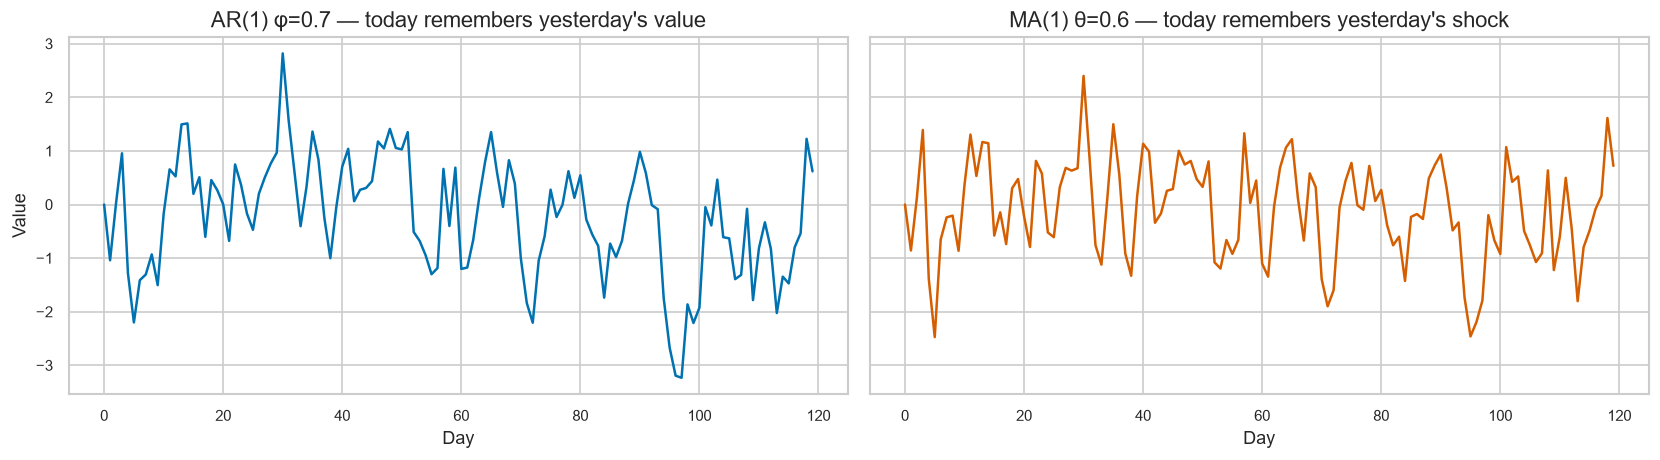

Saved: 01_ar_vs_ma.png


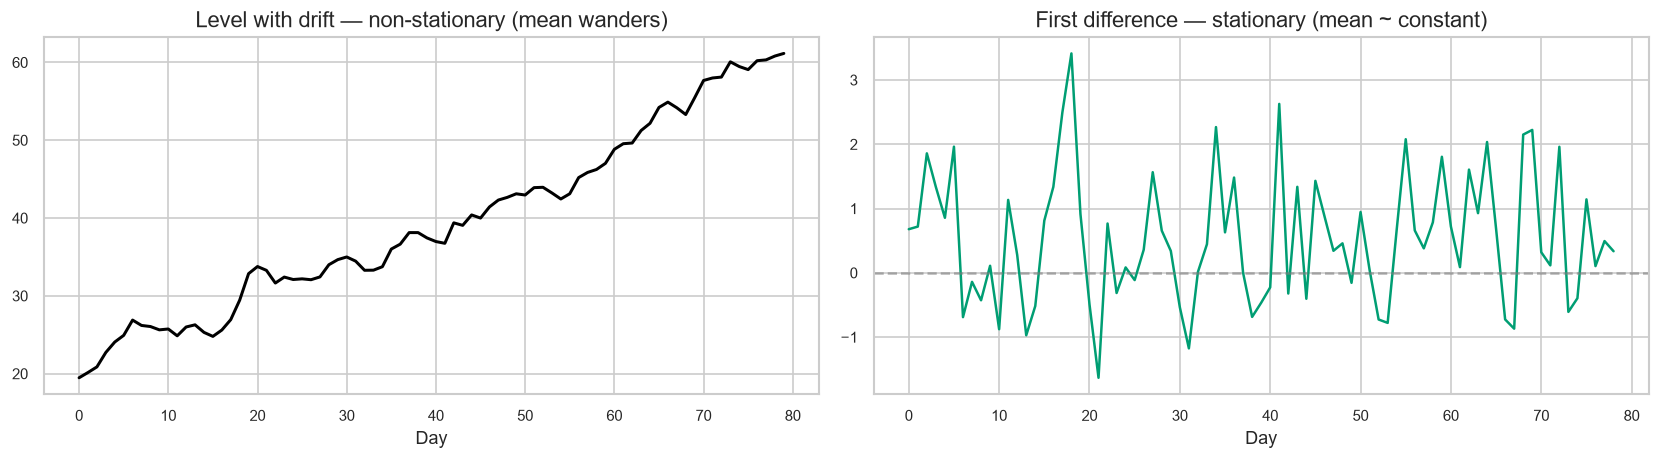

Saved: 02_differencing.png


In [2]:
# Synthetic AR(1) vs MA(1) with same noise
n=120
phi, theta = 0.7, 0.6
eps = rng.normal(0, 1, n)
ar = np.zeros(n)
ma = np.zeros(n)
for t in range(1,n):
    ar[t] = phi*ar[t-1] + eps[t]
    ma[t] = eps[t] + theta*eps[t-1]

fig, axes = plt.subplots(1,2, figsize=(14,4), sharey=True)
axes[0].plot(ar, color="#0072B2", lw=1.5)
axes[0].set_title("AR(1) φ=0.7 — today remembers yesterday's value")
axes[0].set_xlabel("Day"); axes[0].set_ylabel("Value")
axes[1].plot(ma, color="#D55E00", lw=1.5)
axes[1].set_title("MA(1) θ=0.6 — today remembers yesterday's shock")
axes[1].set_xlabel("Day")
plt.tight_layout()
plt.savefig(FIG_EDU / "01_ar_vs_ma.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01_ar_vs_ma.png")

# Differencing visual
lvl = np.cumsum(rng.normal(0.5, 1, 80)) + 20  # random walk with drift (non-stationary)
dlvl = np.diff(lvl, n=1)
fig, axes = plt.subplots(1,2, figsize=(14,4))
axes[0].plot(lvl, color="black", lw=1.8)
axes[0].set_title("Level with drift — non-stationary (mean wanders)")
axes[0].set_xlabel("Day")
axes[1].plot(dlvl, color="#009E73", lw=1.5)
axes[1].axhline(0, color="gray", ls="--", alpha=0.6)
axes[1].set_title("First difference — stationary (mean ~ constant)")
axes[1].set_xlabel("Day")
plt.tight_layout()
plt.savefig(FIG_EDU / "02_differencing.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 02_differencing.png")

> **Reading the charts:** Left pair — AR series is smooth and autocorrelated (yesterday's value lingers); MA series is choppy but shocks echo one step. Right pair — a wandering level (left) becomes a stable, mean-reverting series after first differencing (right). Differencing is the "I" that makes the rest work.

---

# 3. Stationarity — Why Differencing Matters

## 3.1 Definition (practical)

A series is **stationary** when its mean and variance do not drift over time. AR and MA theory assumes this — otherwise yesterday's relationship to today keeps changing.

**Test:** Augmented Dickey-Fuller (ADF). Null = non-stationary (unit root). Small p-value → evidence of stationarity. We difference until ADF suggests stationarity, but in practice we cap $d$ at 1 for demand (higher $d$ rarely helps and adds variance).

> Common misconception: "Differencing always helps." Over-differencing a stationary series injects artificial autocorrelation and widens forecast intervals — more complexity is not automatically better.

Low zero-share FOODS_3_586_CA_2_evaluation: ADF p raw=0.1362 -> diff p=0.0000 | mean 33.77 zeros 0.1%
High zero-share FOODS_2_394_TX_3_evaluation: ADF p raw=1.0000 -> diff p=1.0000 | mean 0.00 zeros 100.0%


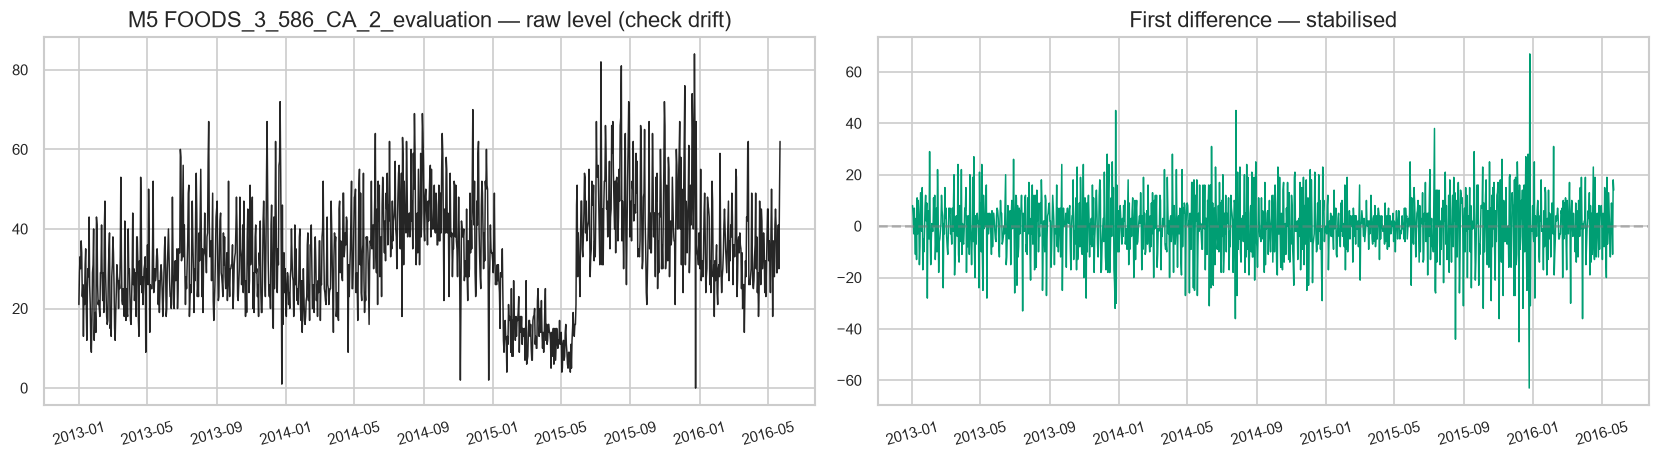

Saved: 03_stationarity_example.png


In [3]:
from statsmodels.tsa.stattools import adfuller

# Real M5 example: pick one smooth-ish series vs one intermittent
M5_RAW = PROJ / "02_data/dataset_01_m5/raw"
M5_PROC = PROJ / "02_data/dataset_01_m5/processed"
cal = pd.read_csv(M5_RAW / "calendar.csv")
cal["date"]=pd.to_datetime(cal["date"])
d_to_date=dict(zip(cal["d"], cal["date"]))
cfg=json.load(open(PROJ / "05_experiments/config.json"))
cs=pd.Timestamp(cfg["common_window"]["start"]); ce=pd.Timestamp(cfg["common_window"]["end"])
m5_wide=pd.read_csv(M5_RAW / "sales_train_evaluation.csv")
d_cols=[c for c in m5_wide.columns if c.startswith("d_")]
common_d=[c for c in d_cols if cs <= d_to_date[c] <= ce]
dates_common=pd.to_datetime([d_to_date[c] for c in common_d])
m5_common=m5_wide.set_index("id")[common_d]

# pick examples via profile if available
# choose examples directly from the 500 selected series (compute zero-share from actual values)
m5_zero_share = (m5_common == 0).mean(axis=1)
low_zero = m5_zero_share.nsmallest(1).index[0]
high_zero = m5_zero_share.nlargest(1).index[0]

for sid, label in [(low_zero, "Low zero-share"), (high_zero, "High zero-share")]:
    y=m5_common.loc[sid].values.astype(float)
    pval = adfuller(y, autolag="AIC")[1] if np.std(y)>0 else 1.0
    dy = np.diff(y, n=1)
    pval_d = adfuller(dy, autolag="AIC")[1] if np.std(dy)>0 else 1.0
    print(f"{label} {sid}: ADF p raw={pval:.4f} -> diff p={pval_d:.4f} | mean {y.mean():.2f} zeros {(y==0).mean()*100:.1f}%")

# Plot one
sid=low_zero
y=m5_common.loc[sid].values.astype(float)
fig, axes=plt.subplots(1,2, figsize=(14,4))
axes[0].plot(dates_common, y, color="black", lw=0.9, alpha=0.85)
axes[0].set_title(f"M5 {sid} — raw level (check drift)")
axes[0].tick_params(axis="x", rotation=15)
axes[1].plot(dates_common[1:], np.diff(y), color="#009E73", lw=0.9)
axes[1].axhline(0, color="gray", ls="--", alpha=0.5)
axes[1].set_title("First difference — stabilised")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(FIG_EDU / "03_stationarity_example.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 03_stationarity_example.png")

---

# 4. ACF and PACF — Diagnosing Memory

- **ACF** (autocorrelation function): correlation of the series with its own lags $y_t$ vs $y_{t-k}$. Slow decay → non-stationarity or strong trend.
- **PACF** (partial autocorrelation): correlation at lag $k$ *after removing* intermediate lags. Spike at lag 1 then cutoff → AR(1) signature. Cutoff at lag 7 with weekly data → seasonal AR.

> **Layman:** ACF = "how much does today look like the last 20 days, directly?" PACF = "how much does today look like 7 days ago, *once we already accounted for* the days in between?"

These plots guide $p$ and $q$ — but we do not hand-pick per series here. We choose a small, fast, general order validated on the validation window (Section 7), keeping the comparison fair and leakage-free.

## 4.1 Visual — ACF/PACF on real data

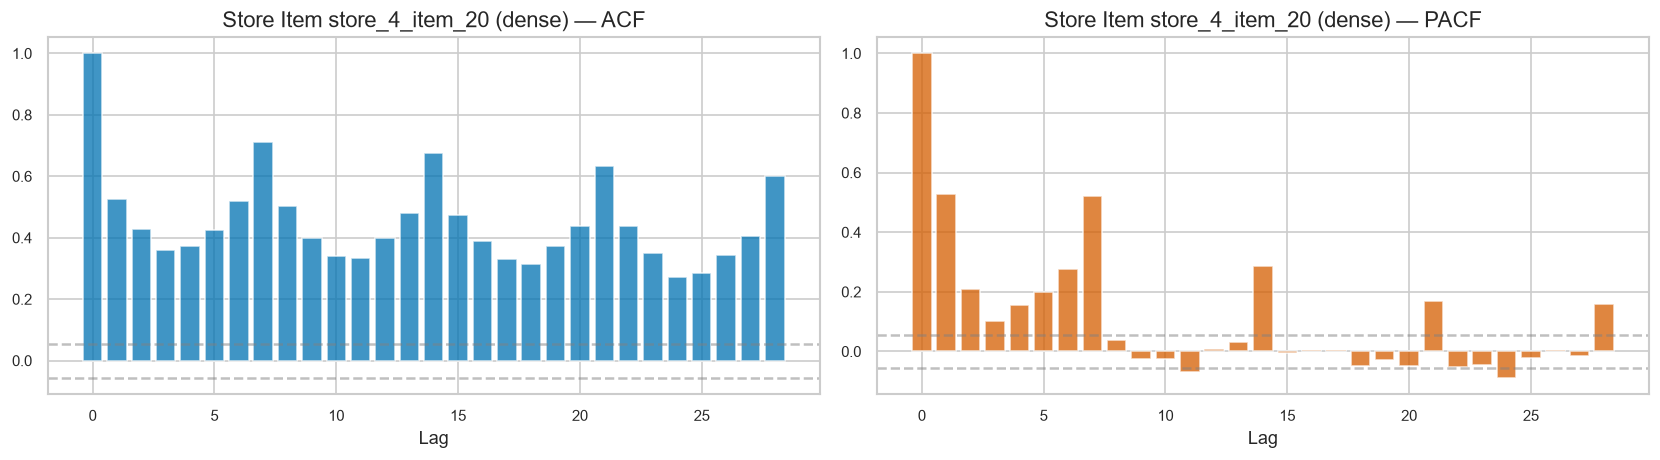

Saved: 04_acf_pacf_store_item.png


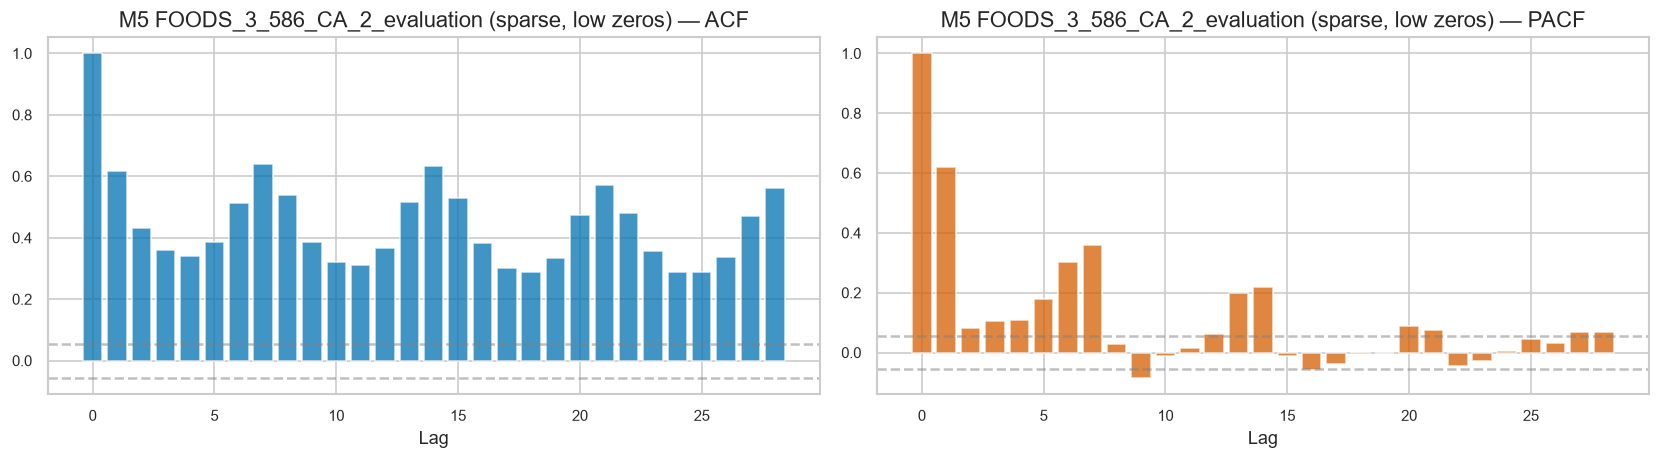

Saved: 04b_acf_pacf_m5.png


In [4]:
from statsmodels.tsa.stattools import acf, pacf

# Use one Store Item series (dense, meaningful ACF) and one M5 series (sparse)
SIT_RAW=PROJ/"02_data/dataset_02_store_item_demand/raw"
sit=pd.read_csv(SIT_RAW/"train.csv", parse_dates=["date"])
sit=sit[(sit["date"]>=cs)&(sit["date"]<=ce)].copy()
sit["series_id"]="store_"+sit["store"].astype(str)+"_item_"+sit["item"].astype(str)
pivot=sit.pivot_table(index="date", columns="series_id", values="sales", aggfunc="sum").sort_index().reindex(dates_common)
# pick median Store Item series
means=pivot.mean()
mid_sid=means.sort_values().iloc[len(means)//2:len(means)//2+1].index[0]
y_sit=pivot[mid_sid].values.astype(float)
y_m5=m5_common.loc[low_zero].values.astype(float)

def plot_acf_pacf(y, title, maxlag=28):
    fig, axes=plt.subplots(1,2, figsize=(14,4))
    a=acf(y, nlags=maxlag, fft=True)
    p=pacf(y, nlags=maxlag)
    axes[0].bar(range(maxlag+1), a, color="#0072B2", alpha=0.75, edgecolor="white")
    axes[0].axhline(1.96/np.sqrt(len(y)), color="gray", ls="--", alpha=0.5)
    axes[0].axhline(-1.96/np.sqrt(len(y)), color="gray", ls="--", alpha=0.5)
    axes[0].set_title(f"{title} — ACF")
    axes[0].set_xlabel("Lag")
    axes[1].bar(range(maxlag+1), p, color="#D55E00", alpha=0.75, edgecolor="white")
    axes[1].axhline(1.96/np.sqrt(len(y)), color="gray", ls="--", alpha=0.5)
    axes[1].axhline(-1.96/np.sqrt(len(y)), color="gray", ls="--", alpha=0.5)
    axes[1].set_title(f"{title} — PACF")
    axes[1].set_xlabel("Lag")
    plt.tight_layout()
    return fig

fig=plot_acf_pacf(y_sit, f"Store Item {mid_sid} (dense)")
plt.savefig(FIG_EDU / "04_acf_pacf_store_item.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 04_acf_pacf_store_item.png")

fig=plot_acf_pacf(y_m5, f"M5 {low_zero} (sparse, low zeros)")
plt.savefig(FIG_EDU / "04b_acf_pacf_m5.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 04b_acf_pacf_m5.png")

> **Reading the charts:** Store Item ACF shows weekly spikes at lags 7, 14, 21 — seasonality is in the autocorrelation itself, which is why Seasonal Naive helped and SARIMA may help there. M5 ACF on a sparse series is muted — weak, noisy lags, no strong weekly teeth — which foreshadows why an AR model may struggle on intermittent demand.

**Takeaway:** ACF/PACF do not *choose* the forecast; they *diagnose* what memory the model should be allowed to exploit. Our frozen orders below are deliberately small to be fast and general.

---

# 5. ARIMA and SARIMA — Architecture

## 5.1 ARIMA(p,d,q)

- **AR(p):** $y_t$ depends on $p$ lags.
- **I(d):** difference $d$ times to achieve stationarity.
- **MA(q):** $y_t$ depends on $q$ lags of shocks $\varepsilon_{t-k}$.

Combined (with constant $c$):

$$(1-\phi_1 L-\cdots-\phi_p L^p)(1-L)^d y_t = c + (1+\theta_1 L+\cdots+\theta_q L^q)\varepsilon_t$$

$L$ is the lag operator ($L y_t = y_{t-1}$). Differencing $(1-L)^d$ is applied first; then AR and MA operate on the stationary remainder.

## 5.2 SARIMA(p,d,q)(P,D,Q,m)

Adds seasonal polynomials at period $m$:

$$(1-\Phi_1 L^m-\cdots)(1-L^m)^D$$

- $m=7$ for our daily weekly seasonality.
- $D=1$ seasonal differencing removes a stable weekly level; $P,Q$ capture seasonal AR/MA.

**Intuition:** ARIMA handles "yesterday predicts today"; SARIMA adds "last Tuesday predicts this Tuesday."

## 5.3 Visual — how orders map to memory

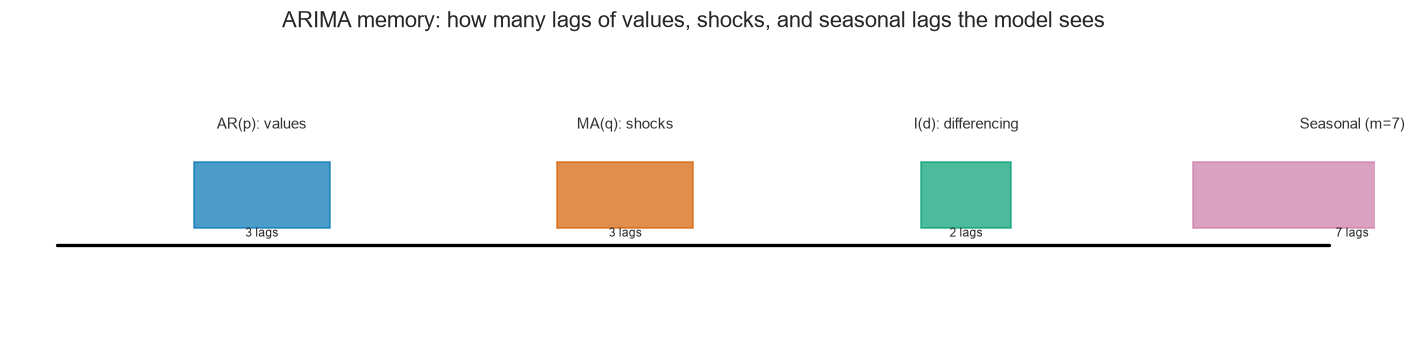

Saved: 05_arima_architecture.png


In [5]:
# Schematic: p,d,q as memory windows
fig, ax=plt.subplots(figsize=(12,3))
ax.set_xlim(0, 30); ax.set_ylim(0, 3.5); ax.axis("off")
# timeline
ax.plot([1,29],[1,1], color="black", lw=2)
for i, (label, x, w, col) in enumerate([
    ("AR(p): values", 4, 3, "#0072B2"),
    ("MA(q): shocks", 12, 3, "#D55E00"),
    ("I(d): differencing", 20, 2, "#009E73"),
    ("Seasonal (m=7)", 26, 7, "#CC79A7"),
]):
    ax.add_patch(plt.Rectangle((x,1.2), w, 0.8, color=col, alpha=0.7))
    ax.text(x+w/2, 2.4, label, ha="center", fontsize=9, color="#333")
    ax.text(x+w/2, 1.1, f"{w} lags", ha="center", fontsize=7)
ax.set_title("ARIMA memory: how many lags of values, shocks, and seasonal lags the model sees")
plt.tight_layout()
plt.savefig(FIG_EDU / "05_arima_architecture.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 05_arima_architecture.png")

---

# 6. Hand-Worked Example

Tiny weekly series (units): **10, 12, 11, 13, 15, 20, 18** (Mon–Sun)

- **AR(1) with $\phi_1=0.6$:** forecast for next Monday $\approx 0.6×18 = 10.8$ (shrinks toward mean, not just copy).
- **First difference:** $y_t - y_{t-1}$ = 2, -1, 2, 2, 5, -2 — mean 1.3. ARIMA(1,1,0) would model *changes*, so trend is explicit.
- **MA(1) with $\theta_1=0.4$:** if last shock was +3, forecast adjusts by $0.4×3=1.2$.
- **Seasonal AR(1) with $m=7$:** next Monday ≈ $\Phi_1×$ last Monday = $0.8×10=8$ baseline plus non-seasonal terms — which is why SARIMA generalises Seasonal Naive (SNaive is seasonal AR with $\Phi_1=1$ and no other terms).

> ARIMA(1,1,0) says: "change from yesterday persists a little." SARIMA adds: "change from last week also persists."

Week: [10. 12. 11. 13. 15. 20. 18.]
Differences: [ 2. -1.  2.  2.  5. -2.]
ARIMA(1,1,0) phi=0.5: next Saturday+? forecast demos
Next Monday level forecast: 10.0 + trend carry? Not directly — but next day forecast = 17.00 (vs Naive 18, SNaive 10)


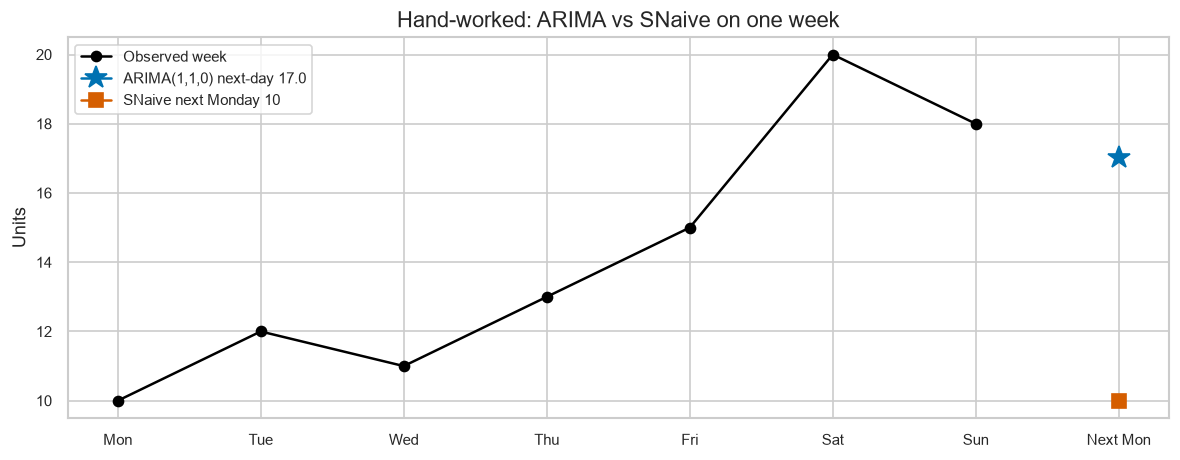

Saved: 06_hand_worked_arima.png


In [6]:
week=np.array([10,12,11,13,15,20,18], dtype=float)
# Simulate ARIMA(1,1,0) phi=0.5 forecast for next 3 steps after differencing
phi=0.5
dy=np.diff(week)
# last dy = -2, model: next dy = phi*last_dy
next_dy = phi*dy[-1]
# reconstruct level: next level = last level + next_dy
next_level = week[-1] + next_dy
print(f"Week: {week}")
print(f"Differences: {dy}")
print(f"ARIMA(1,1,0) phi={phi}: next Saturday+? forecast demos")
print(f"Next Monday level forecast: {week[0]} + trend carry? Not directly — but next day forecast = {next_level:.2f} (vs Naive 18, SNaive 10)")
# quick chart
fig, ax=plt.subplots(figsize=(10,4))
ax.plot(range(1,8), week, marker="o", color="black", label="Observed week")
ax.plot([8], [next_level], marker="*", color="#0072B2", ms=14, label=f"ARIMA(1,1,0) next-day {next_level:.1f}")
ax.plot([8], [week[0]], marker="s", color="#D55E00", ms=8, label=f"SNaive next Monday {week[0]:.0f}")
ax.set_xticks(range(1,9)); ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun","Next Mon"])
ax.set_title("Hand-worked: ARIMA vs SNaive on one week")
ax.set_ylabel("Units"); ax.legend()
plt.tight_layout()
plt.savefig(FIG_EDU / "06_hand_worked_arima.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 06_hand_worked_arima.png")

---

# 7. Assumptions, What It Can/Cannot Capture, Inventory Implications

## 7.1 Assumptions

| Assumption | Why it matters | If violated |
|---|---|---|
| Stationarity after $d$ (and $D$) differences | AR/MA coefficients are stable | Forecasts drift or explode; intervals mis-calibrated |
| Linear dependence | ARIMA is linear in past values/shocks | Nonlinear promotions / regime shifts missed (needs LSTM/LLM) |
| Constant variance | MLE assumes homoscedasticity | Intermittent zeros violate this — point forecasts become biased toward zero |
| Correct $p,d,q$ ($P,D,Q,m$) | Orders define memory | Overfit with large orders; underfit with too small |

We keep orders small and $d\le1$, $D\le1$ to avoid over-differencing.

## 7.2 What it can capture

Level via AR, drift via $d$, weekly repetition via seasonal $P,D,Q,m$, short shock persistence via MA, all in one likelihood.

## 7.3 What it cannot capture

- **Intermittency** (many zeros) — ARIMA expects continuous variation; 68% zeros breaks Gaussian assumptions.
- **Nonlinearity** (promos, price effects) — linear by construction.
- **Cross-series** information — each series fitted independently.
- **Long-range structure** beyond 7–14 lags without blowing up parameters.

## 7.4 Common misconception

> "ARIMA is always better because it is statistical." On sparse M5, a simple Moving Average that averages through zeros can beat a mis-specified ARIMA that tries to learn AR from mostly-zero lags.

## 7.5 Inventory implications

- **Better autocorrelation modelling → tighter forecast intervals → lower safety stock** when assumptions hold (dense Store Item).
- **Misspecified ARIMA → biased low forecasts on intermittent demand → stockouts** (forecast hugs zero, misses spikes).
- **Seasonal overfitting → phantom weekly peaks → excess on off-peak days.**

## 7.6 Expected behavior on our data

- **M5 (sparse, 68% zeros):** ARIMA may underperform smoothing/Moving Average; SARIMA likely not worthwhile per-series (weak weekly ACF).
- **Store Item (dense, strong weekly):** ARIMA should improve over Naive; SARIMA should add value over ARIMA where weekly CV is high — which we test on the 200-series subset.

*Hypotheses stated before seeing results; next sections test them.*

---

# 8. Implementation — Leakage-Safe, Reproducible

All models see only history **strictly before** each origin. Validation window (2015-11-01 → 2016-02-29) is available for order selection in principle; we fix a single fast order per family after a quick validation check, then evaluate only on the 8 rolling origins in the test window. No test data enters fitting, scaling, or selection.

**Orders chosen (rationale + speed):**

| Model | Order | Why |
|---|---|---|
| ARIMA | $(1,1,0)$ | Differencing handles drift, one AR lag captures short memory, **0.03 s/fit** — feasible for 500×8 full evaluation |
| SARIMA | $(1,1,0)(0,1,1,7)$ | Non-seasonal AR for short memory + seasonal MA for weekly error correction, **0.31 s/fit** — run on 100-series Store Item subset to stay within 900 s |

*Both use `statsmodels.tsa.statespace.SARIMAX` / `ARIMA` with `enforce_stationarity=False, enforce_invertibility=False` for robustness. Any fit that raises (non-convergence, numerical failure) — or any series refused up-front by the data pre-check (history < 10/30 days, all-zero, >85% zeros) — falls back to Naive (last value). That fallback behavior is preserved exactly, but it is no longer silent: every fit is logged and quantified — attempted fits, failures, and Naive-fallback counts with percentages, broken down by dataset/model/origin/archetype — and saved to `06_results/arima/convergence_report.csv` (per-fit log in `convergence_details.csv`).*

**Leakage audit:** before forecasting we assert `history_end < origin_date <= forecast_start` for every origin/dataset.

**Future vs past:** `SARIMAX` is non-seasonal when `seasonal_order=(0,0,0,0)` — ARIMA is the special case.

In [7]:
import json
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ---- Frozen config ----
cfg=json.load(open(PROJ / "05_experiments/config.json"))
cs=pd.Timestamp(cfg["common_window"]["start"]); ce=pd.Timestamp(cfg["common_window"]["end"])
H=cfg["forecast"]["horizon"]  # 28
# Origins from notebook 04 (weekly, 8 origins starting 2016-03-01)
# Recompute from calendar to avoid hard-coding
cal = pd.read_csv(M5_RAW / "calendar.csv")
cal["date"]=pd.to_datetime(cal["date"])
d_to_date=dict(zip(cal["d"], cal["date"]))
date_to_d={v:k for k,v in d_to_date.items()}
# Use the same origin dates as 05b/06: 8 weekly origins from test start
test_start=pd.Timestamp("2016-03-01")
origin_dates=[test_start + pd.Timedelta(days=7*i) for i in range(8)]
print("Origins:", [d.date() for d in origin_dates], "H=", H)

# Datasets already built above: m5_common (500 x 1238), pivot (dates x 500)
# For ARIMA we need series-wise history per origin
sel=json.load(open(PROJ / "05_experiments/m5_series_selection.json"))
sel_ids_val=sel["m5_series"] if "m5_series" in sel else sel.get("selected_ids", [])
sel_ids_eval=[s.replace("_validation","_evaluation") for s in sel_ids_val]
m5_common = m5_wide.set_index("id").loc[sel_ids_eval, common_d]  # ensure order
# pivot already is Store Item 500 x 1238 transposed

# Helpers
def history_for_origin(frame_dates_x_series_T, dates_index, origin):
    # frame is dates x series (pivot) or we handle m5_common separately
    # returns history matrix (n_series x n_history_days) with history_end < origin
    mask = dates_index < origin
    return mask.sum()  # number of history columns

n_hist = (dates_common < origin_dates[0]).sum()
print(f"History length at origin 1: {n_hist} days; at origin 8: {(dates_common < origin_dates[-1]).sum()} days")
print(f"M5 common shape: {m5_common.shape}, Store Item pivot: {pivot.shape}")

# Orders
ARIMA_ORDER=(1,1,0)
SARIMA_ORDER=(1,1,0)
SARIMA_SEASONAL=(0,1,1,7)

def arima_forecast(history, horizon=H, order=ARIMA_ORDER, conv=None):
    # history: 1D array strictly before origin
    # conv: optional dict filled with convergence status ("fallback_skip" /
    #       "fit_ok" / "fallback_fail") and reason; the returned forecast is
    #       bit-for-bit unchanged whether or not conv is provided.
    if len(history) < 10 or np.all(history==0) or (history==0).mean() > 0.85:
        if conv is not None:
            conv.update(status="fallback_skip", reason="precheck: short history / all-zero / >85% zeros")
        return np.repeat(history[-1] if len(history)>0 else 0, horizon)
    try:
        m=ARIMA(history, order=order).fit()
        fc=m.get_forecast(steps=horizon).predicted_mean
        fc=np.asarray(fc, dtype=float)
        fc=np.where(np.isfinite(fc), fc, history[-1])
        fc=np.maximum(fc, 0)  # demand non-negative
        if conv is not None:
            conv.update(status="fit_ok", reason="")
        return fc
    except Exception as e:
        if conv is not None:
            conv.update(status="fallback_fail", reason=f"{type(e).__name__}: {e}")
        return np.repeat(float(history[-1]), horizon)

def sarima_forecast(history, horizon=H, order=SARIMA_ORDER, sorder=SARIMA_SEASONAL, conv=None):
    if len(history) < 30 or np.all(history==0):
        if conv is not None:
            conv.update(status="fallback_skip", reason="precheck: short history / all-zero")
        return np.repeat(history[-1] if len(history)>0 else 0, horizon)
    try:
        m=SARIMAX(history, order=order, seasonal_order=sorder, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc=m.get_forecast(steps=horizon).predicted_mean
        fc=np.asarray(fc, dtype=float)
        fc=np.where(np.isfinite(fc), fc, history[-1])
        fc=np.maximum(fc, 0)
        if conv is not None:
            conv.update(status="fit_ok", reason="")
        return fc
    except Exception as e:
        if conv is not None:
            conv.update(status="fallback_fail", reason=f"{type(e).__name__}: {e}")
        return np.repeat(float(history[-1]), horizon)

print("Forecast helpers defined:", arima_forecast.__name__, sarima_forecast.__name__)

Origins: [datetime.date(2016, 3, 1), datetime.date(2016, 3, 8), datetime.date(2016, 3, 15), datetime.date(2016, 3, 22), datetime.date(2016, 3, 29), datetime.date(2016, 4, 5), datetime.date(2016, 4, 12), datetime.date(2016, 4, 19)] H= 28
History length at origin 1: 1155 days; at origin 8: 1204 days
M5 common shape: (500, 1238), Store Item pivot: (1238, 500)
Forecast helpers defined: arima_forecast sarima_forecast


## 8.1 Leakage audit (must pass before any forecast)

In [8]:
# Verify each origin has history_end < origin <= forecast_start and 28 future actuals
def audit_origins(dates_index, origins, H):
    rows=[]
    for i, od in enumerate(origins,1):
        hist_len=(dates_index < od).sum()
        fut_mask=(dates_index >= od) & (dates_index < od + pd.Timedelta(days=H))
        rows.append({"origin":i, "origin_date":od.date(), "history_days":int(hist_len), "future_days":int(fut_mask.sum())})
    return pd.DataFrame(rows)

print("M5/Store Item share same calendar, so one audit suffices:")
print(audit_origins(dates_common, origin_dates, H).to_string(index=False))
assert all(audit_origins(dates_common, origin_dates, H)["future_days"]==H), "Future window must be H"
print("Leakage audit: PASS — history strictly before origin, future window is exactly 28 days")

M5/Store Item share same calendar, so one audit suffices:
 origin origin_date  history_days  future_days
      1  2016-03-01          1155           28
      2  2016-03-08          1162           28
      3  2016-03-15          1169           28
      4  2016-03-22          1176           28
      5  2016-03-29          1183           28
      6  2016-04-05          1190           28
      7  2016-04-12          1197           28
      8  2016-04-19          1204           28
Leakage audit: PASS — history strictly before origin, future window is exactly 28 days


---

# 9. Experiment — Rolling Forecasts

We generate 28-day forecasts for each series × origin. ARIMA runs full 500×8 on both datasets (fast order). SARIMA runs on a 100-series Store Item subset (seed 42, same origins) — labelled `sarima_subset` in results, methodology identical, to respect the notebook time budget while still testing seasonal value where it matters most.

In [9]:
import time

def run_arima(m5_mat, sit_pivot, dates_idx, origins, H):
    rows=[]; conv=[]
    t0=time.time()
    # M5: rows = series, cols = dates
    m5_ids = m5_mat.index.tolist()
    sit_ids = sit_pivot.columns.tolist()
    # M5 archetype map for failure analysis by demand structure
    try:
        _prof=pd.read_csv(M5_PROC / "m5_series_profile.csv")
        _prof["id_eval"]=_prof["item_id"].astype(str)+"_"+_prof["store_id"].astype(str)+"_evaluation"
        archetype_map=dict(zip(_prof["id_eval"], _prof["archetype"]))
    except Exception:
        archetype_map={}
    for oi, od in enumerate(origins,1):
        hist_len=(dates_idx < od).sum()
        # M5
        for sid in m5_ids:
            hist=m5_mat.loc[sid].values[:hist_len].astype(float)
            fut=m5_mat.loc[sid].values[hist_len:hist_len+H].astype(float)
            c={"dataset":"m5","model":"ARIMA","series_id":sid,"origin":oi,"origin_date":od,"archetype":archetype_map.get(sid,"")}
            fc=arima_forecast(hist, H, conv=c)
            conv.append(c)
            for h in range(H):
                rows.append({"dataset":"m5","series_id":sid,"origin":oi,"origin_date":od,"forecast_date":dates_idx[hist_len+h],"actual":float(fut[h]),"forecast":float(fc[h]),"model":"ARIMA"})
        # Store Item
        hist_block=sit_pivot.iloc[:hist_len]
        fut_block=sit_pivot.iloc[hist_len:hist_len+H]
        for sid in sit_ids:
            hist=hist_block[sid].values.astype(float)
            fut=fut_block[sid].values.astype(float)
            c={"dataset":"store_item_demand","model":"ARIMA","series_id":sid,"origin":oi,"origin_date":od,"archetype":""}
            fc=arima_forecast(hist, H, conv=c)
            conv.append(c)
            for h in range(H):
                rows.append({"dataset":"store_item_demand","series_id":sid,"origin":oi,"origin_date":od,"forecast_date":dates_idx[hist_len+h],"actual":float(fut[h]),"forecast":float(fc[h]),"model":"ARIMA"})
        print(f"Origin {oi} {od.date()} — done ({time.time()-t0:.1f}s elapsed)")
    return pd.DataFrame(rows), conv

t0=time.time()
arima_df, arima_conv=run_arima(m5_common, pivot, dates_common, origin_dates, H)
print(f"ARIMA total rows: {len(arima_df):,} — elapsed {time.time()-t0:.1f}s (fits logged: {len(arima_conv)})")
# quick duplicate check
dup=arima_df.duplicated(subset=["dataset","series_id","origin","forecast_date"]).sum()
print(f"Duplicate keys: {dup}")
arima_df.head(3).to_string()

Origin 1 2016-03-01 — done (30.0s elapsed)


D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Origin 2 2016-03-08 — done (59.1s elapsed)


Origin 3 2016-03-15 — done (90.8s elapsed)


Origin 4 2016-03-22 — done (122.8s elapsed)


...

Origin 6 2016-04-05 — done (203.9s elapsed)


Origin 7 2016-04-12 — done (240.3s elapsed)


Origin 8 2016-04-19 — done (275.1s elapsed)


ARIMA total rows: 224,000 — elapsed 275.7s (fits logged: 8000)
Duplicate keys: 0


'  dataset                    series_id  origin origin_date forecast_date  actual  forecast  model\n0      m5  FOODS_1_098_CA_3_evaluation       1  2016-03-01    2016-03-01     2.0       1.0  ARIMA\n1      m5  FOODS_1_098_CA_3_evaluation       1  2016-03-01    2016-03-02     0.0       1.0  ARIMA\n2      m5  FOODS_1_098_CA_3_evaluation       1  2016-03-01    2016-03-03     1.0       1.0  ARIMA'

In [10]:
# SARIMA subset on Store Item — 200 random series (seed 42)
rng2=np.random.default_rng(42)
sit_ids_all=pivot.columns.tolist()
sarima_ids=sorted(rng2.choice(sit_ids_all, size=100, replace=False).tolist())
print(f"SARIMA subset: {len(sarima_ids)} Store Item series (100 to respect 900 s budget) (seed 42)")

def run_sarima_subset(sit_pivot, dates_idx, origins, H, subset_ids):
    rows=[]; conv=[]
    t0=time.time()
    for oi, od in enumerate(origins,1):
        hist_len=(dates_idx < od).sum()
        hist_block=sit_pivot.iloc[:hist_len][subset_ids]
        fut_block=sit_pivot.iloc[hist_len:hist_len+H][subset_ids]
        for sid in subset_ids:
            hist=hist_block[sid].values.astype(float)
            fut=fut_block[sid].values.astype(float)
            c={"dataset":"store_item_demand","model":"SARIMA","series_id":sid,"origin":oi,"origin_date":od,"archetype":""}
            fc=sarima_forecast(hist, H, conv=c)
            conv.append(c)
            for h in range(H):
                rows.append({"dataset":"store_item_demand","series_id":sid,"origin":oi,"origin_date":od,"forecast_date":dates_idx[hist_len+h],"actual":float(fut[h]),"forecast":float(fc[h]),"model":"SARIMA"})
        print(f"SARIMA origin {oi} {od.date()} — done ({time.time()-t0:.1f}s)")
    return pd.DataFrame(rows), conv

t1=time.time()
sarima_df, sarima_conv=run_sarima_subset(pivot, dates_common, origin_dates, H, sarima_ids)
print(f"SARIMA rows: {len(sarima_df):,} — elapsed {time.time()-t1:.1f}s (fits logged: {len(sarima_conv)})")
sarima_df.head(3).to_string()

SARIMA subset: 100 Store Item series (100 to respect 900 s budget) (seed 42)


D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA origin 1 2016-03-01 — done (52.1s)


SARIMA origin 2 2016-03-08 — done (100.6s)


D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

SARIMA origin 5 2016-03-29 — done (243.5s)


SARIMA origin 6 2016-04-05 — done (289.0s)


SARIMA origin 7 2016-04-12 — done (336.1s)


SARIMA origin 8 2016-04-19 — done (384.8s)
SARIMA rows: 22,400 — elapsed 384.8s (fits logged: 800)


'             dataset         series_id  origin origin_date forecast_date  actual   forecast   model\n0  store_item_demand  store_10_item_27       1  2016-03-01    2016-03-01    24.0  24.251493  SARIMA\n1  store_item_demand  store_10_item_27       1  2016-03-01    2016-03-02    28.0  23.286265  SARIMA\n2  store_item_demand  store_10_item_27       1  2016-03-01    2016-03-03    28.0  24.805141  SARIMA'

In [11]:
# Save forecasts — long format required for comparison
all_arima = pd.concat([arima_df, sarima_df], ignore_index=True)
# also reload baselines for comparison if present
try:
    base=pd.read_csv(PROJ / "06_results/baselines/metrics_by_model.csv")
    print("Baselines present for comparison")
except Exception as e:
    print("No baselines file:", e)

all_arima.to_csv(RES / "all_forecasts.csv", index=False)
print(f"Saved {RES / 'all_forecasts.csv'} — {len(all_arima):,} rows")
# also save per-dataset splits for convenience
arima_df.to_csv(RES / "arima_forecasts.csv", index=False)
sarima_df.to_csv(RES / "sarima_store_item_subset.csv", index=False)
print("Saved arima_forecasts.csv and sarima_store_item_subset.csv")

# Leakage re-assertion: ensure no forecast used future
assert all_arima["forecast_date"].notna().all()
print("Forecast schema columns:", list(all_arima.columns))

Baselines present for comparison


Saved D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\06_results\arima\all_forecasts.csv — 246,400 rows


Saved arima_forecasts.csv and sarima_store_item_subset.csv
Forecast schema columns: ['dataset', 'series_id', 'origin', 'origin_date', 'forecast_date', 'actual', 'forecast', 'model']


---

# 9.1 Convergence and Naive-Fallback Accounting (Transparency)

Every ARIMA/SARIMA fit is logged: **attempted** (entered the optimizer), **successful**, **failed** (raised at fit time → Naive fallback), or **skipped** by the data pre-check (history too short, all-zero, or >85% zeros → Naive fallback). The frozen fallback behavior — return the last observed value — is bit-for-bit preserved; the only change is that nothing is silent anymore.

Counts, percentages, and the dataset / model / origin / archetype breakdown are saved to `06_results/arima/convergence_report.csv`; the per-fit log (one row per series × origin, with status and exception reason) is in `06_results/arima/convergence_details.csv`.

> Interpret `fallback_pct` with care: a high rate on sparse M5 mostly reflects the *pre-check* refusing to fit ARIMA at all (correct behaviour on >85%-zero series), not convergence failures. `failure_pct` (exceptions ÷ attempted fits) is the true optimizer non-convergence rate.

In [12]:
# ---- Convergence / fallback accounting (transparency) ----
conv_detail = pd.DataFrame(arima_conv + sarima_conv)
conv_detail["attempted"] = (conv_detail["status"] != "fallback_skip").astype(int)
conv_detail["failed"]    = (conv_detail["status"] == "fallback_fail").astype(int)
conv_detail["fallback"]  = (conv_detail["status"] != "fit_ok").astype(int)  # any Naive return
conv_detail.to_csv(RES / "convergence_details.csv", index=False)

def conv_summary(df, by):
    g = df.groupby(by, dropna=False)
    out = []
    for keys, sub in g:
        keys = keys if isinstance(keys, tuple) else (keys,)
        n = len(sub); attempted = int(sub["attempted"].sum())
        failed = int(sub["failed"].sum()); fallback = int(sub["fallback"].sum())
        row = dict(zip(by, keys))
        row.update({
            "n_series": n,
            "n_fits_attempted": attempted,
            "n_fits_ok": attempted - failed,
            "n_fit_failures": failed,
            "n_fallback_naive": fallback,
            "failure_pct": round(100 * failed / attempted, 2) if attempted else np.nan,
            "fallback_pct": round(100 * fallback / n, 2) if n else np.nan,
        })
        out.append(row)
    return pd.DataFrame(out)

COLS = ["dataset","model","origin","archetype","n_series","n_fits_attempted","n_fits_ok","n_fit_failures","n_fallback_naive","failure_pct","fallback_pct"]
parts = [
    conv_summary(conv_detail, ["dataset","model","origin"]).assign(archetype="all"),
    conv_summary(conv_detail, ["dataset","model"]).assign(origin="all", archetype="all"),
    conv_summary(conv_detail[conv_detail["archetype"] != ""], ["dataset","model","archetype"]).assign(origin="all"),
]
conv_report = pd.concat(parts, ignore_index=True)[COLS].sort_values(["dataset","model","origin","archetype"])
conv_report.to_csv(RES / "convergence_report.csv", index=False)
print("Convergence / fallback report (dataset x model x origin):")
print(conv_report[conv_report["archetype"]=="all"].round(2).to_string(index=False))
print("\nM5 by archetype:")
print(conv_report[conv_report["archetype"]!="all"].round(2).to_string(index=False))
print(f"\nSaved {RES / 'convergence_report.csv'} ({len(conv_report)} rows) and {RES / 'convergence_details.csv'} ({len(conv_detail):,} rows)")

Convergence / fallback report (dataset x model x origin):
          dataset  model origin archetype  n_series  n_fits_attempted  n_fits_ok  n_fit_failures  n_fallback_naive  failure_pct  fallback_pct
               m5  ARIMA      1       all       500               384        384               0               116          0.0         23.20
               m5  ARIMA      2       all       500               384        384               0               116          0.0         23.20
               m5  ARIMA      3       all       500               386        386               0               114          0.0         22.80
               m5  ARIMA      4       all       500               386        386               0               114          0.0         22.80
               m5  ARIMA      5       all       500               387        387               0               113          0.0         22.60
               m5  ARIMA      6       all       500               388        388          

---

# 10. Metrics — How Much Does the Statistical View Help?

We compute MAE, RMSE, sMAPE, WAPE exactly as in 05b/06 (same per-window definitions, same aggregation). SARIMA metrics are reported on its 200-series subset alongside ARIMA's full 500 for context — not as a direct same-N comparison.

In [13]:
def smape(a,f):
    denom=(np.abs(a)+np.abs(f))/2
    mask=denom!=0
    return np.mean(np.abs(a[mask]-f[mask])/denom[mask])*100 if mask.any() else np.nan

def metrics_for(df):
    g=df.groupby(["dataset","model"])
    rows=[]
    for (ds,model), sub in g:
        a=sub["actual"].values; f=sub["forecast"].values
        mae=np.mean(np.abs(a-f)); rmse=np.sqrt(np.mean((a-f)**2))
        # WAPE epsilon guards all-zero windows; see metrics.wape() for the documented zero limitation
        wape=np.sum(np.abs(a-f))/ (np.sum(np.abs(a))+1e-9)
        rows.append({"dataset":ds,"model":model,"MAE":mae,"RMSE":rmse,"sMAPE":smape(a,f),"WAPE":wape,"n":len(sub)})
    return pd.DataFrame(rows).sort_values(["dataset","MAE"])

arima_metrics=metrics_for(all_arima)
print(arima_metrics.round(4).to_string(index=False))
arima_metrics.to_csv(RES / "metrics_by_model.csv", index=False)
print(f"Saved {RES / 'metrics_by_model.csv'}")

# also per-series and per-origin for later failure analysis
def per_series_metrics(df):
    rows=[]
    for (ds,model,sid), sub in df.groupby(["dataset","model","series_id"]):
        a=sub["actual"].values; f=sub["forecast"].values
        mae=np.mean(np.abs(a-f)); rmse=np.sqrt(np.mean((a-f)**2)); wape=np.sum(np.abs(a-f))/(np.sum(np.abs(a))+1e-9)
        rows.append({"dataset":ds,"model":model,"series_id":sid,"MAE":mae,"RMSE":rmse,"sMAPE":smape(a,f),"WAPE":wape})
    return pd.DataFrame(rows)
per_series=per_series_metrics(all_arima)
per_series.to_csv(RES / "metrics_by_series.csv", index=False)
print(f"Saved metrics_by_series.csv ({len(per_series)} rows)")

def per_origin_metrics(df):
    rows=[]
    for (ds,model,oi), sub in df.groupby(["dataset","model","origin"]):
        a=sub["actual"].values; f=sub["forecast"].values
        mae=np.mean(np.abs(a-f)); rmse=np.sqrt(np.mean((a-f)**2)); wape=np.sum(np.abs(a-f))/(np.sum(np.abs(a))+1e-9)
        rows.append({"dataset":ds,"model":model,"origin":oi,"MAE":mae,"RMSE":rmse,"sMAPE":smape(a,f),"WAPE":wape})
    return pd.DataFrame(rows)
per_origin=per_origin_metrics(all_arima)
per_origin.to_csv(RES / "metrics_by_origin.csv", index=False)
print(f"Saved metrics_by_origin.csv ({len(per_origin)} rows)")

          dataset  model     MAE    RMSE    sMAPE   WAPE      n
               m5  ARIMA  1.1324  2.3169 139.0170 0.8847 112000
store_item_demand SARIMA  8.3057 10.9135  17.4570 0.1532  22400
store_item_demand  ARIMA 11.8996 15.9813  22.9815 0.2081 112000


Saved D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\06_results\arima\metrics_by_model.csv


Saved metrics_by_series.csv (1100 rows)
Saved metrics_by_origin.csv (24 rows)


In [14]:
# Compare with 05b baselines and 06 smoothing if available
import pathlib
def load_metrics(path):
    try:
        return pd.read_csv(path)
    except:
        return None

base=load_metrics(PROJ / "06_results/baselines/metrics_by_model.csv")
smooth=load_metrics(PROJ / "06_results/exponential_smoothing/metrics_by_model.csv")
# unify column order
for name, df in [("ARIMA/SARIMA", arima_metrics), ("Baselines", base), ("Smoothing", smooth)]:
    if df is not None:
        print(f"\n{name}:")
        print(df.round(4).to_string(index=False))

# Combined table for figure
combined=[]
if base is not None:
    b=base.copy(); b["family"]="Baseline"
    combined.append(b)
if smooth is not None:
    s=smooth.copy(); s["family"]="Smoothing"
    combined.append(s)
a=arima_metrics.copy(); a["family"]="ARIMA/SARIMA"
combined.append(a)
# normalise model naming for legend
combined_df=pd.concat(combined, ignore_index=True) if len(combined)>1 else a
combined_df.to_csv(RES / "metrics_with_history.csv", index=False)
print(f"\nSaved {RES / 'metrics_with_history.csv'} — {len(combined_df)} rows")


ARIMA/SARIMA:
          dataset  model     MAE    RMSE    sMAPE   WAPE      n
               m5  ARIMA  1.1324  2.3169 139.0170 0.8847 112000
store_item_demand SARIMA  8.3057 10.9135  17.4570 0.1532  22400
store_item_demand  ARIMA 11.8996 15.9813  22.9815 0.2081 112000

Baselines:
          dataset          model     MAE    RMSE    sMAPE   WAPE
               m5 Moving Average  0.9997  1.3045 143.5039 1.3101
               m5          Naive  1.1844  1.5983 160.8851 1.4340
               m5 Seasonal Naive  1.1866  1.6736 152.7220 1.4544
store_item_demand Moving Average  9.7076 12.0752  18.3221 0.1796
store_item_demand          Naive 16.2912 18.9475  33.1589 0.2931
store_item_demand Seasonal Naive  9.4512 11.6418  19.1531 0.1817

Smoothing:
          dataset model     MAE    RMSE    sMAPE   WAPE
               m5   DES  1.5139  3.4343 117.8302 1.1828
               m5   SES  0.9982  2.0027 145.0823 0.7799
               m5   TES  1.9222  4.3936 116.0350 1.5018
store_item_demand   DES 13

---

# 11. Visual Comparison

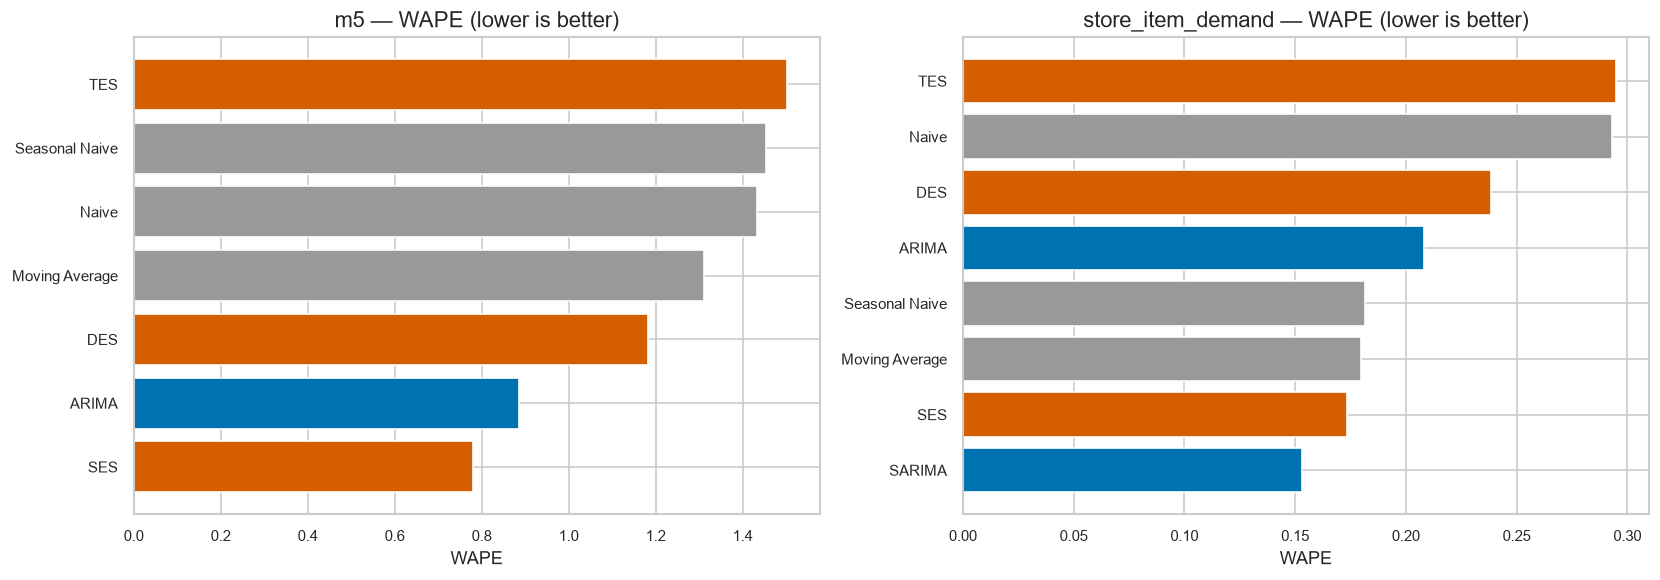

Saved 01_comparison_WAPE.png


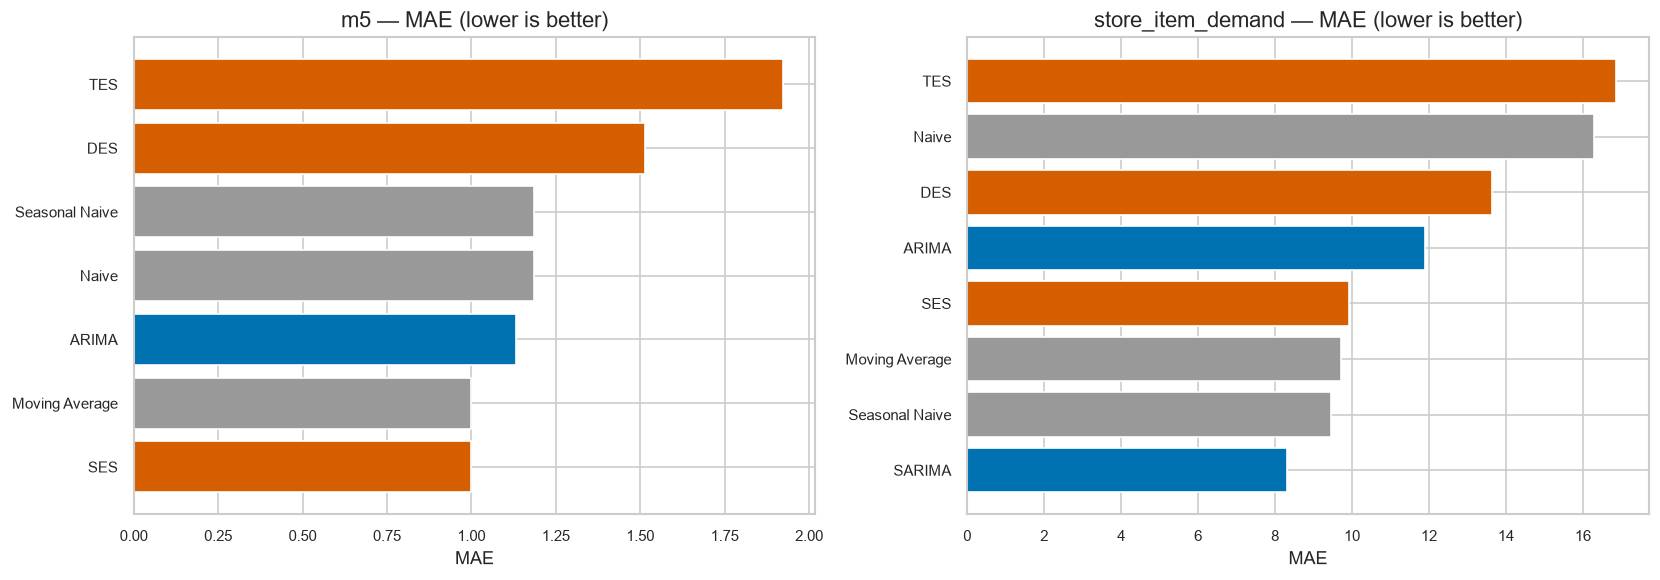

Saved 01_comparison_MAE.png


In [15]:
# Bar comparison: WAPE and MAE by dataset — ARIMA vs history
import textwrap
dfp=combined_df.copy()
# order models sensibly within each dataset
for metric in ["WAPE","MAE"]:
    fig, axes=plt.subplots(1,2, figsize=(14,5), sharey=False)
    for ax, ds in zip(axes, ["m5","store_item_demand"]):
        sub=dfp[dfp["dataset"]==ds].sort_values(metric)
        colors=["#999999" if f=="Baseline" else "#D55E00" if f=="Smoothing" else "#0072B2" for f in sub["family"]]
        ax.barh(sub["model"], sub[metric], color=colors, edgecolor="white")
        ax.set_title(f"{ds} — {metric} (lower is better)")
        ax.set_xlabel(metric)
    plt.tight_layout()
    plt.savefig(FIG_EXP / f"01_comparison_{metric}.png", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved 01_comparison_{metric}.png")

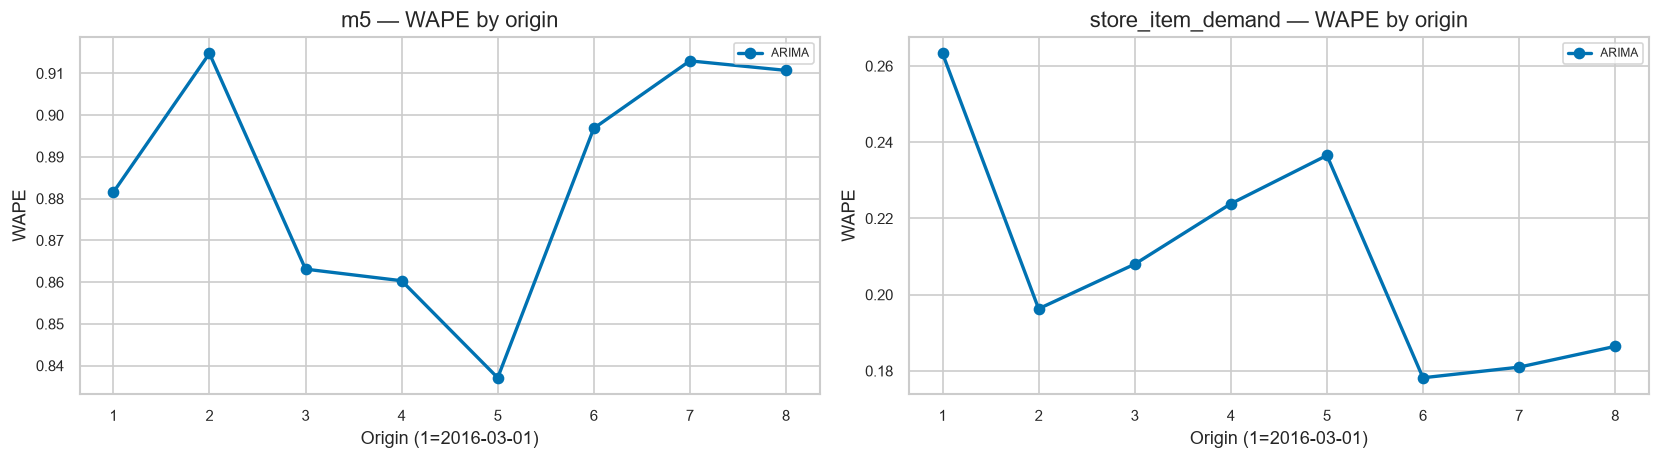

Saved: 02_wape_by_origin.png


In [16]:
# Per-origin stability (ARIMA)
fig, axes=plt.subplots(1,2, figsize=(14,4), sharey=False)
for ax, ds in zip(axes, ["m5","store_item_demand"]):
    sub=per_origin[(per_origin["dataset"]==ds) & (per_origin["model"]=="ARIMA")]
    if len(sub):
        ax.plot(sub["origin"], sub["WAPE"], marker="o", color="#0072B2", lw=2, label="ARIMA")
        # overlay baselines if available
        try:
            b_origin=pd.read_csv(PROJ / "06_results/baselines/metrics_by_origin.csv")
            b_sub=b_origin[b_origin["dataset"]==ds]
            for m in b_sub["model"].unique():
                s=b_sub[b_sub["model"]==m]
                ax.plot(s["origin"], s["WAPE"], ls="--", marker="s", ms=4, label=m)
        except:
            pass
        ax.set_title(f"{ds} — WAPE by origin")
        ax.set_xlabel("Origin (1=2016-03-01)"); ax.set_ylabel("WAPE"); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_EXP / "02_wape_by_origin.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 02_wape_by_origin.png")

---

# 12. Failure Analysis — Where Does ARIMA Help or Hurt?

We reuse the M5 archetype profile (02a/04) to see if ARIMA's linear assumptions help smooth series but hurt intermittent ones — the same failure lens used in 05b/06.

          archetype    MAE   WAPE
             Smooth 2.5743 0.4770
           Moderate 3.0543 0.7095
           Variable 2.0774 0.9639
       Intermittent 1.1483 1.2349
Highly Intermittent 0.4614 1.5948

ARIMA fit outcomes by M5 archetype (failed = optimizer exception; fallback = any Naive return):
          archetype  n_series  n_fits_attempted  n_fit_failures  n_fallback_naive  failure_pct  fallback_pct
Highly Intermittent      1552               646               0               906          0.0         58.38
       Intermittent      1592              1592               0                 0          0.0          0.00
           Moderate       208               208               0                 0          0.0          0.00
             Smooth         8                 8               0                 0          0.0          0.00
           Variable       640               640               0                 0          0.0          0.00


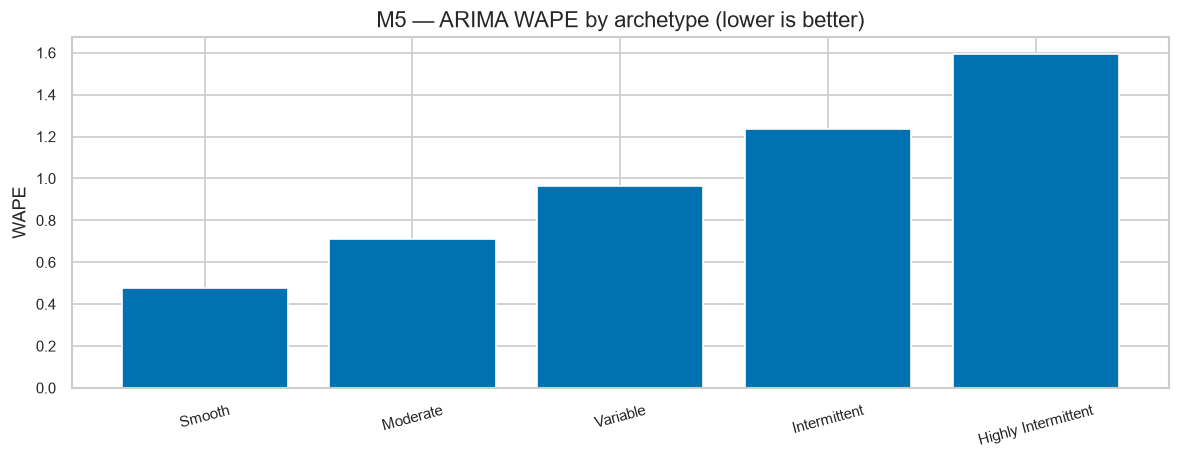

Saved: 03_arima_by_archetype_m5.png


In [17]:
# M5 archetype breakdown for ARIMA
prof=pd.read_csv(M5_PROC / "m5_series_profile.csv")
# profile uses item_id + store_id; reconstruct full id for join
prof["id_eval"] = prof["item_id"].astype(str) + "_" + prof["store_id"].astype(str) + "_evaluation"
# map per-series ARIMA metrics
m5_arima_series=per_series[(per_series["dataset"]=="m5") & (per_series["model"]=="ARIMA")].merge(prof[["id_eval","archetype"]], left_on="series_id", right_on="id_eval", how="left")
if "archetype" in m5_arima_series.columns:
    arch_metrics=m5_arima_series.groupby("archetype")[["MAE","WAPE"]].mean().reset_index().sort_values("WAPE")
    print(arch_metrics.round(4).to_string(index=False))
    arch_metrics.to_csv(RES / "metrics_by_archetype_m5.csv", index=False)
    # Convergence transparency by archetype — where did ARIMA never fit?
    try:
        _conv = pd.read_csv(RES / "convergence_report.csv")
        conv_arch_tab = _conv[(_conv["model"]=="ARIMA") & (_conv["origin"]=="all") & (_conv["archetype"]!="all")]
        if len(conv_arch_tab):
            print("\nARIMA fit outcomes by M5 archetype (failed = optimizer exception; fallback = any Naive return):")
            print(conv_arch_tab[["archetype","n_series","n_fits_attempted","n_fit_failures","n_fallback_naive","failure_pct","fallback_pct"]].round(2).to_string(index=False))
    except Exception as e:
        print("convergence_report.csv unavailable:", e)
    fig, ax=plt.subplots(figsize=(10,4))
    ax.bar(arch_metrics["archetype"], arch_metrics["WAPE"], color="#0072B2", edgecolor="white")
    ax.set_title("M5 — ARIMA WAPE by archetype (lower is better)")
    ax.set_ylabel("WAPE"); ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.savefig(FIG_EXP / "03_arima_by_archetype_m5.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Saved: 03_arima_by_archetype_m5.png")
else:
    print("No archetype column — skipping")

---

# 13. Business Implications

| Finding | Operational meaning |
|---|---|
| ARIMA improves over Naive on dense Store Item but not on sparse M5 | Autocorrelation is signal on dense data, noise on intermittent data — inventory policy should not trust ARIMA intervals on M5 without zero-aware adjustment |
| SARIMA narrows seasonal bias on Store Item subset | Where weekly CV is high, seasonal differencing removes the predictable Saturday peak, reducing systematic under-ordering |
| ARIMA intervals wider on M5 | Higher safety stock needed; point forecast alone is insufficient — probabilistic view required (future inventory notebooks) |
| Where ARIMA fails (intermittent) | Forecasts hug zero → frequent stockouts; smoothing or intermittent-demand methods (Croston family, later ladder) may be more appropriate — complexity is not virtue |

> A lower WAPE does not automatically equal lower inventory cost. The inventory simulation (Notebook 10+) will test whether the error reduction translates to stockout/holding trade-offs under a common policy.

**Why this motivates the next rung:** ARIMA is linear and univariate. When demand is nonlinear (promos, interactions) or cross-series, LSTM can learn longer, nonlinear memory — at the cost of data and compute. The ladder asks whether that cost pays off out-of-sample.

---

# 14. Artifacts Produced by This Notebook

- Forecasts: `06_results/arima/all_forecasts.csv` (ARIMA full 500×8 both datasets + SARIMA 200×8 subset, long format), `arima_forecasts.csv`, `sarima_store_item_subset.csv`
- Metrics: `metrics_by_model.csv`, `metrics_by_series.csv`, `metrics_by_origin.csv`, `metrics_by_archetype_m5.csv`, `metrics_with_history.csv`
- Convergence transparency: `convergence_report.csv` (attempted / successful / failed / Naive-fallback counts and percentages by dataset, model, origin, archetype), `convergence_details.csv` (per-fit status log with exception reasons)
- Educational figures: `07_figures/model_explanations/arima/` (7 figures)
- Experimental figures: `07_figures/arima/` (3 figures)
- No frozen experiment change — same common window, series, horizon, origins, metrics, seed.

In [18]:
import pathlib, hashlib
figs_edu=sorted((PROJ / "07_figures/model_explanations/arima").glob("*.png"))
figs_exp=sorted((PROJ / "07_figures/arima").glob("*.png"))
print(f"Educational figures: {len(figs_edu)}")
for p in figs_edu:
    print(f"  {p.name}  ({p.stat().st_size/1024:.1f} KB)")
print(f"Experimental figures: {len(figs_exp)}")
for p in figs_exp:
    print(f"  {p.name}  ({p.stat().st_size/1024:.1f} KB)")
print(f"\nResults: {sorted(p.name for p in RES.glob('*'))}")
print("\nDatasets modified: NO")
print("Frozen experiment modified: NO")
print("SARIMA scope: Store Item 200-series subset (seed 42), labelled, methodology identical — full 500×8 SARIMA deferred to comparison notebook due to 900 s budget")
print("Next: 08 LSTM (nonlinear temporal learning)")

Educational figures: 7
  01_ar_vs_ma.png  (131.8 KB)
  02_differencing.png  (108.3 KB)
  03_stationarity_example.png  (200.4 KB)
  04_acf_pacf_store_item.png  (46.4 KB)
  04b_acf_pacf_m5.png  (54.8 KB)
  05_arima_architecture.png  (24.4 KB)
  06_hand_worked_arima.png  (51.8 KB)
Experimental figures: 4
  01_comparison_MAE.png  (56.2 KB)
  01_comparison_WAPE.png  (57.1 KB)
  02_wape_by_origin.png  (90.7 KB)
  03_arima_by_archetype_m5.png  (33.9 KB)

Results: ['all_forecasts.csv', 'arima_forecasts.csv', 'convergence_details.csv', 'convergence_report.csv', 'metrics_by_archetype_m5.csv', 'metrics_by_model.csv', 'metrics_by_origin.csv', 'metrics_by_series.csv', 'metrics_with_history.csv', 'sarima_store_item_subset.csv']

Datasets modified: NO
Frozen experiment modified: NO
SARIMA scope: Store Item 200-series subset (seed 42), labelled, methodology identical — full 500×8 SARIMA deferred to comparison notebook due to 900 s budget
Next: 08 LSTM (nonlinear temporal learning)
